# DATA OVERVIEW


## 1. Tổng quan về dataset

**European Soccer Database** là dataset lịch sử về bóng đá chuyên nghiệp châu Âu, được Hugo Mathien công bố trên Kaggle dưới định dạng SQLite. Theo documented metadata, dataset bao phủ hơn 25.000 trận đấu, hơn 10.000 cầu thủ và dữ liệu từ 11 quốc gia trong giai đoạn 2008-2016. Các số liệu thực tế của file `database.sqlite` sẽ được xác nhận lại trong các phần sau.

### 1.1. Nguồn và phạm vi

| Nhóm dữ liệu | Nguồn được ghi nhận | Nội dung chính |
|---|---|---|
| Trận đấu, đội, cầu thủ | football-data.mx-api.enetscores.com | Lịch thi đấu, kết quả, đội bóng, cầu thủ |
| Thuộc tính cầu thủ và đội | SoFIFA | Chỉ số chuyên môn theo thời gian |
| Betting odds | football-data.co.uk | Tỷ lệ cược trước trận |

### 1.2. Phương pháp thu thập và lưu ý sử dụng

Metadata của dataset cho biết dữ liệu được thu thập bằng Python/Scrapy và kết hợp từ nhiều nguồn. Vì vậy, các trường `api_id`, `fifa_api_id` và các bảng thuộc tính cần được kiểm tra về uniqueness, `NULL`, duplicate và khả năng liên kết trước khi sử dụng cho phân tích.

Dataset được phát hành theo ODbL và phù hợp cho mục đích học tập, phân tích dữ liệu và xây dựng dashboard. Notebook này chỉ khảo sát cấu trúc database nguồn, không chỉnh sửa dữ liệu và không tạo analytical tables.


## 2. Kết nối và đọc dữ liệu SQLite

Phần này kết nối file `database.sqlite` bằng `sqlite3` ở chế độ `read-only` và chạy một truy vấn nhỏ để xác nhận database có thể đọc được.


In [1]:
import re
import sys
from pathlib import Path

import pandas as pd
from graphviz import Digraph

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import (
    check_foreign_key_integrity,
    check_functional_dependency,
    connect_sqlite_readonly,
    count_table_rows,
    get_table_schema,
    list_user_tables,
    profile_key_candidate,
    profile_relationship_cardinality,
    quote_identifier,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)

DATABASE_PATH = (PROJECT_ROOT / "data" / "raw" / "database.sqlite").resolve()
connection = connect_sqlite_readonly(DATABASE_PATH)

connection_test = pd.read_sql_query(
    """
    SELECT COUNT(*) AS table_count
    FROM sqlite_master
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%';
    """,
    connection,
)

display(connection_test)


,table_count
0,7


**Nhận xét**

Kết nối `read-only` đã đọc được database và truy vấn metadata trả về 7 bảng nghiệp vụ. Notebook chỉ đọc dữ liệu để kiểm tra cấu trúc, không ghi ngược vào `database.sqlite`.


## 3. Liệt kê các bảng trong database

Phần này lấy danh sách bảng nghiệp vụ từ `sqlite_master` để xác định phạm vi khảo sát của database nguồn.


In [2]:
tables = list_user_tables(connection)
canonical_table_names = {
    table_name.lower(): table_name
    for table_name in tables["table_name"]
}

display(tables)


,table_name
0,Country
1,League
2,Match
3,Player
4,Player_Attributes
5,Team
6,Team_Attributes


**Nhận xét**

Database gồm 7 bảng nghiệp vụ. `Match` là bảng sự kiện trung tâm; `Country`, `League`, `Team` và `Player` là các bảng mô tả; `Team_Attributes` và `Player_Attributes` lưu các snapshot thuộc tính theo thời gian.


## 4. Thống kê quy mô các bảng

Phần này thống kê số dòng và số cột của từng bảng để nhận diện khác biệt về quy mô và `grain` trước khi khảo sát schema chi tiết.


In [3]:
table_size_records = []
for table_name in tables["table_name"]:
    schema = get_table_schema(connection, table_name)
    table_size_records.append(
        {
            "table_name": table_name,
            "row_count": count_table_rows(connection, table_name),
            "column_count": int(schema.shape[0]),
        }
    )

table_size = (
    pd.DataFrame(table_size_records)
    .sort_values("row_count", ascending=False)
    .reset_index(drop=True)
)

display(table_size)


,table_name,row_count,column_count
0,Player_Attributes,183978,42
1,Match,25979,115
2,Player,11060,7
3,Team_Attributes,1458,25
4,Team,299,5
5,League,11,3
6,Country,11,2


**Nhận xét**

`Player_Attributes` có nhiều dòng nhất vì một cầu thủ có thể có nhiều snapshot thuộc tính. `Match` có nhiều cột nhất do chứa kết quả, đội hình, event XML-like và betting odds trong cùng một bảng rộng. Sự khác biệt về quy mô phản ánh các `grain` khác nhau: bảng mô tả nhỏ, bảng sự kiện lớn và bảng thuộc tính thay đổi theo thời gian.


## 5. Khảo sát schema và dữ liệu mẫu

Phần này tạo `database_schema` đầy đủ để dùng lại ở các bước sau, nhưng chỉ hiển thị summary và một vài bảng đại diện để giảm output.


In [4]:
schema_records = [
    get_table_schema(connection, table_name)
    for table_name in tables["table_name"]
]

database_schema = pd.concat(schema_records, ignore_index=True)
database_schema = database_schema[
    ["table_name", "cid", "column_name", "data_type", "not_null", "dflt_value", "primary_key"]
]

primary_key_summary = (
    database_schema.loc[database_schema["primary_key"] > 0]
    .groupby("table_name")["column_name"]
    .agg(", ".join)
    .reset_index(name="primary_key_columns")
)
schema_summary = (
    database_schema.groupby("table_name", as_index=False)
    .agg(
        column_count=("column_name", "count"),
        declared_types=("data_type", lambda values: ", ".join(sorted({str(v) for v in values if str(v)}))),
    )
    .merge(primary_key_summary, on="table_name", how="left")
    .sort_values("table_name")
)

display(schema_summary)


,table_name,column_count,declared_types,primary_key_columns
0,Country,2,"INTEGER, TEXT",id
1,League,3,"INTEGER, TEXT",id
2,Match,115,"INTEGER, NUMERIC, TEXT",id
3,Player,7,"INTEGER, TEXT",id
4,Player_Attributes,42,"INTEGER, TEXT",id
5,Team,5,"INTEGER, TEXT",id
6,Team_Attributes,25,"INTEGER, TEXT",id


In [5]:
representative_schema_columns = {
    "Match": [
        "id",
        "country_id",
        "league_id",
        "season",
        "stage",
        "date",
        "match_api_id",
        "home_team_api_id",
        "away_team_api_id",
        "home_team_goal",
        "away_team_goal",
    ],
    "Team_Attributes": [
        "id",
        "team_api_id",
        "team_fifa_api_id",
        "date",
        "buildUpPlaySpeed",
        "buildUpPlayPassing",
        "chanceCreationShooting",
        "defencePressure",
        "defenceAggression",
    ],
}
representative_schema = database_schema.loc[
    database_schema.apply(
        lambda row: row["column_name"] in representative_schema_columns.get(row["table_name"], []),
        axis=1,
    ),
    ["table_name", "column_name", "data_type", "primary_key"],
].reset_index(drop=True)

display(representative_schema)


,table_name,column_name,data_type,primary_key
0,Match,id,INTEGER,1
1,Match,country_id,INTEGER,0
2,Match,league_id,INTEGER,0
3,Match,season,TEXT,0
4,Match,stage,INTEGER,0
5,Match,date,TEXT,0
6,Match,match_api_id,INTEGER,0
7,Match,home_team_api_id,INTEGER,0
8,Match,away_team_api_id,INTEGER,0
9,Match,home_team_goal,INTEGER,0


In [6]:
def preview_table(table_name: str, columns: list[str], limit: int = 5) -> pd.DataFrame:
    quoted_table = quote_identifier(table_name)
    quoted_columns = ", ".join(quote_identifier(column) for column in columns)
    query = f"SELECT {quoted_columns} FROM {quoted_table} LIMIT {limit};"
    return pd.read_sql_query(query, connection)


match_preview_columns = [
    "id",
    "country_id",
    "league_id",
    "season",
    "stage",
    "date",
    "match_api_id",
    "home_team_api_id",
    "away_team_api_id",
    "home_team_goal",
    "away_team_goal",
]
team_attribute_preview_columns = [
    "id",
    "team_api_id",
    "date",
    "buildUpPlaySpeed",
    "chanceCreationPassing",
    "defencePressure",
]

country_preview = preview_table("Country", ["id", "name"], limit=5)
match_preview = preview_table("Match", match_preview_columns, limit=5)
team_attributes_preview = preview_table("Team_Attributes", team_attribute_preview_columns, limit=5)

display(country_preview)
display(match_preview)
display(team_attributes_preview)


,id,name
0,1,Belgium
1,1729,England
2,4769,France
3,7809,Germany
4,10257,Italy


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,1
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,0
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,3
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,0
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,3


,id,team_api_id,date,buildUpPlaySpeed,chanceCreationPassing,defencePressure
0,1,9930,2010-02-22 00:00:00,60,60,50
1,2,9930,2014-09-19 00:00:00,52,54,47
2,3,9930,2015-09-10 00:00:00,47,54,47
3,4,8485,2010-02-22 00:00:00,70,70,60
4,5,8485,2011-02-22 00:00:00,47,53,47


**Nhận xét**

Schema summary xác nhận tất cả bảng đều có `id` làm primary key; schema chi tiết chỉ hiển thị các cột đại diện của `Match` và `Team_Attributes` và các kiểu dữ liệu chủ yếu là `INTEGER`, `TEXT` và `NUMERIC`. `Match` là bảng rộng nhất, trong khi `Team_Attributes` đại diện cho nhóm bảng snapshot có identifier và ngày ghi nhận. Các cột `api_id` là identifier nguồn quan trọng và cần được kiểm tra riêng về uniqueness và referential integrity.


## 6. Xác định grain và ý nghĩa nghiệp vụ

`Grain` mô tả một dòng trong bảng đại diện cho thực thể, sự kiện hoặc snapshot nào. Phần này chỉ mô tả database nguồn, chưa xây dựng analytical model.


In [7]:
grain_records = [
    {
        "table_name": "Country",
        "grain": "Một quốc gia",
        "business_meaning": "Danh mục quốc gia",
        "table_role": "Dimension-like",
    },
    {
        "table_name": "League",
        "grain": "Một giải đấu trong dataset",
        "business_meaning": "Danh mục giải đấu và quốc gia tương ứng",
        "table_role": "Dimension-like",
    },
    {
        "table_name": "Match",
        "grain": "Một trận đấu",
        "business_meaning": "Kết quả, đội tham gia, đội hình, event và odds",
        "table_role": "Event",
    },
    {
        "table_name": "Player",
        "grain": "Một cầu thủ",
        "business_meaning": "Thông tin mô tả cầu thủ",
        "table_role": "Dimension-like",
    },
    {
        "table_name": "Player_Attributes",
        "grain": "Một bản ghi snapshot thuộc tính cầu thủ tại một lần ghi nhận, định danh bằng id",
        "business_meaning": "Thuộc tính cầu thủ theo thời gian",
        "table_role": "Historical snapshot",
    },
    {
        "table_name": "Team",
        "grain": "Một đội bóng",
        "business_meaning": "Thông tin mô tả đội bóng",
        "table_role": "Dimension-like",
    },
    {
        "table_name": "Team_Attributes",
        "grain": "Một bản ghi snapshot thuộc tính đội bóng tại một lần ghi nhận, định danh bằng id",
        "business_meaning": "Thuộc tính chiến thuật đội bóng theo thời gian",
        "table_role": "Historical snapshot",
    },
]

table_grain = (
    pd.DataFrame(grain_records)
    .merge(table_size, on="table_name", how="left")
    .sort_values("table_name")
    .reset_index(drop=True)
)

display(table_grain)


,table_name,grain,business_meaning,table_role,row_count,column_count
0,Country,Một quốc gia,Danh mục quốc gia,Dimension-like,11,2
1,League,Một giải đấu trong dataset,Danh mục giải đấu và quốc gia tương ứng,Dimension-like,11,3
2,Match,Một trận đấu,"Kết quả, đội tham gia, đội hình, event và odds",Event,25979,115
3,Player,Một cầu thủ,Thông tin mô tả cầu thủ,Dimension-like,11060,7
4,Player_Attributes,Một bản ghi snapshot thuộc tính cầu thủ tại mộ...,Thuộc tính cầu thủ theo thời gian,Historical snapshot,183978,42
5,Team,Một đội bóng,Thông tin mô tả đội bóng,Dimension-like,299,5
6,Team_Attributes,Một bản ghi snapshot thuộc tính đội bóng tại m...,Thuộc tính chiến thuật đội bóng theo thời gian,Historical snapshot,1458,25


**Nhận xét**

Các bảng có thể chia thành ba nhóm: dimension-like, event và historical snapshot. Với `Player_Attributes` và `Team_Attributes`, identifier kết hợp với `date` chưa được xem là grain duy nhất vì cần kiểm tra duplicate business key. Do đó, `id` vẫn là định danh duy nhất an toàn ở database nguồn.


## 7. Xác định primary key, candidate key và foreign key

Phần này kiểm tra các key được khai báo, các candidate key tiềm năng và toàn bộ foreign key constraint trong SQLite schema.


### 7.1. Primary key

Kiểm tra primary key được khai báo trong schema SQLite.


In [8]:
declared_primary_keys = (
    database_schema.loc[database_schema["primary_key"] > 0]
    .sort_values(["table_name", "primary_key"])
    .groupby("table_name", as_index=False)
    .agg(primary_key_columns=("column_name", ", ".join))
)

display(declared_primary_keys)


,table_name,primary_key_columns
0,Country,id
1,League,id
2,Match,id
3,Player,id
4,Player_Attributes,id
5,Team,id
6,Team_Attributes,id


**Nhận xét**

Cả 7 bảng đều dùng `id` làm `primary key`, đây là technical key ổn định trong SQLite schema. Các identifier nguồn như `match_api_id`, `team_api_id`, `player_api_id` và các `FIFA ID` cần được kiểm tra riêng trước khi dùng làm key nghiệp vụ.


### 7.2. Candidate key

Phần này profile một số key tiềm năng thường dùng trong phân tích, gồm `id`, `api_id`, `FIFA ID` và tổ hợp identifier + `date` ở bảng thuộc tính.


In [9]:
candidate_key_definitions = {
    "Country": [["id"], ["name"]],
    "League": [["id"], ["name"]],
    "Match": [["id"], ["match_api_id"]],
    "Player": [["id"], ["player_api_id"], ["player_fifa_api_id"]],
    "Player_Attributes": [["id"], ["player_api_id", "date"], ["player_fifa_api_id", "date"]],
    "Team": [["id"], ["team_api_id"], ["team_fifa_api_id"]],
    "Team_Attributes": [["id"], ["team_api_id", "date"], ["team_fifa_api_id", "date"]],
}

candidate_key_report = pd.DataFrame(
    [
        profile_key_candidate(connection, table_name, key_columns)
        for table_name, key_candidates in candidate_key_definitions.items()
        for key_columns in key_candidates
    ]
).sort_values(["unique_and_not_null", "table_name", "key_columns"], ascending=[False, True, True])

candidate_key_display = candidate_key_report[
    ["table_name", "key_columns", "null_key_rows", "duplicate_key_groups", "unique_and_not_null"]
]

display(candidate_key_display)


,table_name,key_columns,null_key_rows,duplicate_key_groups,unique_and_not_null
0,Country,id,0,0,True
1,Country,name,0,0,True
2,League,id,0,0,True
3,League,name,0,0,True
4,Match,id,0,0,True
5,Match,match_api_id,0,0,True
6,Player,id,0,0,True
7,Player,player_api_id,0,0,True
8,Player,player_fifa_api_id,0,0,True
9,Player_Attributes,id,0,0,True


**Nhận xét**

`id` hợp lệ ở mọi bảng, còn `match_api_id`, `team_api_id` và `player_api_id` là các identifier nguồn đáng tin cậy trong dữ liệu hiện tại. `Country.name` và `League.name` chỉ là candidate key quan sát được trong dataset này, không nhất thiết là business key ổn định ở mọi bối cảnh. `team_fifa_api_id` có `NULL` hoặc duplicate, còn các tổ hợp `api_id + date` ở bảng thuộc tính chưa đủ điều kiện làm candidate key do duplicate hoặc `NULL`.


### 7.3. Foreign key được khai báo

Phần này đọc toàn bộ foreign key vật lý bằng `PRAGMA foreign_key_list()` và tổng hợp theo bảng con.


In [10]:
declared_foreign_key_records = []
for table_name in tables["table_name"]:
    foreign_keys = pd.read_sql_query(
        f"PRAGMA foreign_key_list({quote_identifier(table_name)});",
        connection,
    )
    if not foreign_keys.empty:
        foreign_keys["child_table"] = table_name
        declared_foreign_key_records.append(foreign_keys)

declared_foreign_keys = pd.concat(declared_foreign_key_records, ignore_index=True).rename(
    columns={
        "table": "parent_table",
        "from": "child_column",
        "to": "parent_column",
    }
)
declared_foreign_keys["parent_table"] = declared_foreign_keys["parent_table"].map(
    lambda table_name: canonical_table_names.get(str(table_name).lower(), table_name)
)

declared_foreign_keys = declared_foreign_keys[
    [
        "child_table",
        "id",
        "seq",
        "parent_table",
        "child_column",
        "parent_column",
        "on_update",
        "on_delete",
        "match",
    ]
].sort_values(["child_table", "id", "seq"])

foreign_key_summary = (
    declared_foreign_keys.groupby("child_table", as_index=False)
    .agg(
        foreign_key_count=("child_column", "count"),
        parent_tables=("parent_table", lambda values: ", ".join(sorted(set(values)))),
        update_delete_rule=("on_delete", lambda values: ", ".join(sorted(set(values)))),
    )
    .sort_values("foreign_key_count", ascending=False)
)

display(foreign_key_summary)


,child_table,foreign_key_count,parent_tables,update_delete_rule
1,Match,26,"Country, League, Player, Team",NO ACTION
2,Player_Attributes,2,Player,NO ACTION
3,Team_Attributes,2,Team,NO ACTION
0,League,1,Country,NO ACTION


**Nhận xét**

SQLite schema khai báo 31 `foreign key` vật lý, tập trung nhiều nhất ở bảng `Match` do 22 cột đội hình cầu thủ cùng các liên kết tới quốc gia, league và đội bóng. Các relationship tham chiếu cả `id` lẫn `api_id`, không chỉ primary key nội bộ. Quy tắc update/delete đều là `NO ACTION`, nên database không tự động cascade thay đổi.


### 7.4. Referential integrity

Phần này kiểm tra đủ 31 foreign keys đã khai báo. Output chính tách thành các relationship không thuộc đội hình và summary riêng cho 22 lineup foreign keys của `Match`.


In [11]:
foreign_key_integrity_report = pd.DataFrame(
    [
        check_foreign_key_integrity(
            connection,
            row["child_table"],
            row["child_column"],
            row["parent_table"],
            row["parent_column"],
        )
        for _, row in declared_foreign_keys.iterrows()
    ]
)

lineup_fk_mask = (
    (foreign_key_integrity_report["child_table"] == "Match")
    & foreign_key_integrity_report["child_column"].str.contains(r"^(?:home|away)_player_", regex=True)
)

main_foreign_key_integrity = foreign_key_integrity_report.loc[~lineup_fk_mask].reset_index(drop=True)
lineup_fk_summary = pd.DataFrame([
    {
        "relationship_group": "Match lineup player foreign keys",
        "relationship_count": int(lineup_fk_mask.sum()),
        "total_non_null_rows": int(foreign_key_integrity_report.loc[lineup_fk_mask, "non_null_child_rows"].sum()),
        "total_orphan_keys": int(foreign_key_integrity_report.loc[lineup_fk_mask, "orphan_key_count"].sum()),
        "total_orphan_rows": int(foreign_key_integrity_report.loc[lineup_fk_mask, "orphan_row_count"].sum()),
        "all_valid": bool(foreign_key_integrity_report.loc[lineup_fk_mask, "all_valid"].all()),
    }
])

display(main_foreign_key_integrity)
display(lineup_fk_summary)


,child_table,child_column,parent_table,parent_column,non_null_child_rows,orphan_key_count,orphan_row_count,all_valid
0,League,country_id,Country,id,11,0,0,True
1,Match,away_team_api_id,Team,team_api_id,25979,0,0,True
2,Match,home_team_api_id,Team,team_api_id,25979,0,0,True
3,Match,league_id,League,id,25979,0,0,True
4,Match,country_id,Country,id,25979,0,0,True
5,Player_Attributes,player_api_id,Player,player_api_id,183978,0,0,True
6,Player_Attributes,player_fifa_api_id,Player,player_fifa_api_id,183978,2,49,False
7,Team_Attributes,team_api_id,Team,team_api_id,1458,0,0,True
8,Team_Attributes,team_fifa_api_id,Team,team_fifa_api_id,1458,0,0,True


,relationship_group,relationship_count,total_non_null_rows,total_orphan_keys,total_orphan_rows,all_valid
0,Match lineup player foreign keys,22,542281,0,0,True


**Nhận xét**

Notebook đã kiểm tra đủ 31 `foreign key` được khai báo. Các relationship chính đều hợp lệ ngoại trừ `Player_Attributes.player_fifa_api_id → Player.player_fifa_api_id`, có orphan rows; 22 lineup foreign keys của `Match` được tổng hợp riêng và không có orphan rows. Kết quả này cho thấy `player_api_id` ổn định hơn `player_fifa_api_id` cho liên kết cầu thủ.


## 8. Kiểm tra relationship và cardinality

Phần này dùng cùng nguồn `declared_foreign_keys` và kết quả referential integrity để đánh giá `observed cardinality` trong dataset.


In [12]:
cardinality_report = pd.DataFrame(
    [
        profile_relationship_cardinality(
            connection,
            row["child_table"],
            row["child_column"],
            row["parent_table"],
            row["parent_column"],
        )
        for _, row in declared_foreign_keys.iterrows()
    ]
)

main_cardinality_report = (
    cardinality_report.loc[~lineup_fk_mask]
    .merge(
        main_foreign_key_integrity[
            [
                "child_table",
                "child_column",
                "parent_table",
                "parent_column",
                "orphan_row_count",
                "all_valid",
            ]
        ],
        on=["child_table", "child_column", "parent_table", "parent_column"],
        how="left",
    )
    .reset_index(drop=True)
)

lineup_cardinality_summary = pd.DataFrame([
    {
        "relationship_group": "Match lineup player foreign keys",
        "relationship_count": int(lineup_fk_mask.sum()),
        "observed_cardinality": "Player 1:N Match lineup columns",
        "all_valid": bool(lineup_fk_summary.loc[0, "all_valid"]),
    }
])

display(main_cardinality_report)
display(lineup_cardinality_summary)


,child_table,child_column,parent_table,parent_column,parent_has_duplicate_keys,max_child_rows_per_key,observed_cardinality,orphan_row_count,all_valid
0,League,country_id,Country,id,False,1,1:1 observed,0,True
1,Match,away_team_api_id,Team,team_api_id,False,153,1:N observed,0,True
2,Match,home_team_api_id,Team,team_api_id,False,152,1:N observed,0,True
3,Match,league_id,League,id,False,3040,1:N observed,0,True
4,Match,country_id,Country,id,False,3040,1:N observed,0,True
5,Player_Attributes,player_api_id,Player,player_api_id,False,56,1:N observed,0,True
6,Player_Attributes,player_fifa_api_id,Player,player_fifa_api_id,False,96,1:N observed,49,False
7,Team_Attributes,team_api_id,Team,team_api_id,False,6,1:N observed,0,True
8,Team_Attributes,team_fifa_api_id,Team,team_fifa_api_id,True,8,Parent key không unique,0,True


,relationship_group,relationship_count,observed_cardinality,all_valid
0,Match lineup player foreign keys,22,Player 1:N Match lineup columns,True


**Nhận xét**

Phần lớn relationship chính có `observed cardinality` là `1:N`. `Country.id → League.country_id` là `1:1 observed` vì dataset hiện chỉ có một league cho mỗi quốc gia, nhưng ERD vẫn có thể biểu diễn `Country 1:N League` theo business cardinality tổng quát. Các relationship dùng `team_api_id` và `player_api_id` đáng tin cậy hơn các relationship dùng `FIFA ID`, vì `Team.team_fifa_api_id` không unique và `Player_Attributes.player_fifa_api_id` có orphan rows.


## 9. Xác định functional dependency

Phần này chỉ kiểm tra các `functional dependency` quan trọng cho normalization và identifier consistency, thay vì hiển thị toàn bộ dependency hiển nhiên từ primary key.


In [13]:
functional_dependency_definitions = [
    {
        "table_name": "Match",
        "determinant_columns": ["league_id"],
        "dependent_columns": ["country_id"],
        "dependency_type": "Potential transitive dependency",
    },
    {
        "table_name": "Team_Attributes",
        "determinant_columns": ["team_api_id"],
        "dependent_columns": ["team_fifa_api_id"],
        "dependency_type": "Identifier consistency",
    },
    {
        "table_name": "Player_Attributes",
        "determinant_columns": ["player_api_id"],
        "dependent_columns": ["player_fifa_api_id"],
        "dependency_type": "Identifier consistency",
    },
    {
        "table_name": "Team_Attributes",
        "determinant_columns": ["team_api_id", "date"],
        "dependent_columns": [
            "buildUpPlaySpeed",
            "buildUpPlayPassing",
            "chanceCreationPassing",
            "defencePressure",
        ],
        "dependency_type": "Snapshot business key check",
    },
    {
        "table_name": "Player_Attributes",
        "determinant_columns": ["player_api_id", "date"],
        "dependent_columns": [
            "overall_rating",
            "potential",
            "preferred_foot",
            "attacking_work_rate",
            "defensive_work_rate",
        ],
        "dependency_type": "Snapshot business key check",
    },
]

functional_dependency_records = []
for definition in functional_dependency_definitions:
    for dependent_column in definition["dependent_columns"]:
        functional_dependency_records.append(
            check_functional_dependency(
                connection=connection,
                table_name=definition["table_name"],
                determinant_columns=definition["determinant_columns"],
                dependent_column=dependent_column,
                dependency_type=definition["dependency_type"],
            )
        )

functional_dependency_report = pd.DataFrame(functional_dependency_records)
violated_dependencies = functional_dependency_report.loc[
    functional_dependency_report["dependency_status"] == "Violated"
].reset_index(drop=True)

normalization_dependencies = functional_dependency_report.sort_values(
    ["table_name", "determinant", "dependent"]
).reset_index(drop=True)

display(normalization_dependencies)
display(violated_dependencies)


,table_name,determinant,dependent,dependency_type,max_dependent_values,violation_group_count,dependency_status
0,Match,league_id,country_id,Potential transitive dependency,1,0,Supported
1,Player_Attributes,player_api_id,player_fifa_api_id,Identifier consistency,2,9,Violated
2,Player_Attributes,player_api_id + date,attacking_work_rate,Snapshot business key check,2,784,Violated
3,Player_Attributes,player_api_id + date,defensive_work_rate,Snapshot business key check,2,835,Violated
4,Player_Attributes,player_api_id + date,overall_rating,Snapshot business key check,2,835,Violated
5,Player_Attributes,player_api_id + date,potential,Snapshot business key check,2,835,Violated
6,Player_Attributes,player_api_id + date,preferred_foot,Snapshot business key check,2,835,Violated
7,Team_Attributes,team_api_id,team_fifa_api_id,Identifier consistency,1,0,Supported
8,Team_Attributes,team_api_id + date,buildUpPlayPassing,Snapshot business key check,1,0,Supported
9,Team_Attributes,team_api_id + date,buildUpPlaySpeed,Snapshot business key check,1,0,Supported


,table_name,determinant,dependent,dependency_type,max_dependent_values,violation_group_count,dependency_status
0,Player_Attributes,player_api_id,player_fifa_api_id,Identifier consistency,2,9,Violated
1,Player_Attributes,player_api_id + date,overall_rating,Snapshot business key check,2,835,Violated
2,Player_Attributes,player_api_id + date,potential,Snapshot business key check,2,835,Violated
3,Player_Attributes,player_api_id + date,preferred_foot,Snapshot business key check,2,835,Violated
4,Player_Attributes,player_api_id + date,attacking_work_rate,Snapshot business key check,2,784,Violated
5,Player_Attributes,player_api_id + date,defensive_work_rate,Snapshot business key check,2,835,Violated


**Nhận xét**

Phần lớn dependency quan trọng được dữ liệu hỗ trợ, nhưng không phải tất cả. `Player_Attributes` vi phạm `player_api_id → player_fifa_api_id` và các dependency từ `player_api_id + date`, cho thấy identifier và business key của bảng này chưa ổn định. `Team_Attributes.team_api_id + date` được hỗ trợ với các thuộc tính được kiểm tra, nhưng tổ hợp này vẫn không phải candidate key vì có duplicate. `Match.league_id → country_id` được hỗ trợ trong dataset hiện tại và là dấu hiệu dư thừa cần xét ở normalization.


## 10. Kiểm tra 1NF, 2NF, 3NF và BCNF

Phần này đánh giá normalization bằng các kiểm tra thực hành trên schema và một tập `functional dependency` đã xác định. Kết luận được diễn đạt thận trọng vì tập FD không thể bảo đảm đầy đủ toàn bộ business rules.


### 10.1. 1NF

Kiểm tra `primary key`, repeating groups và các cột text có dấu hiệu XML/list-like values. Đây là heuristic để nhận diện vấn đề thiết kế, không phải chứng minh hình thức tuyệt đối.


In [14]:
def detect_repeating_groups(columns: list[str]) -> list[str]:
    groups: dict[str, list[str]] = {}
    for column in columns:
        match = re.match(r"^(.*?)(?:_)?(\d+)$", column)
        if match and column != "id":
            group_name = match.group(1).rstrip("_")
            groups.setdefault(group_name, []).append(column)
    return [group_name for group_name, group_columns in groups.items() if len(group_columns) > 1]


repeating_group_records = []
for table_name, group in database_schema.groupby("table_name"):
    table_columns = group["column_name"].tolist()
    repeating_groups = detect_repeating_groups(table_columns)
    repeating_group_records.append(
        {
            "table_name": table_name,
            "repeating_group_count": len(repeating_groups),
            "repeating_groups": ", ".join(repeating_groups[:8]),
        }
    )
repeating_group_report = pd.DataFrame(repeating_group_records)

text_columns = database_schema.loc[
    database_schema["data_type"].fillna("").str.upper().str.contains(r"TEXT|CHAR|CLOB", regex=True),
    ["table_name", "column_name"],
]

suspicious_text_records = []
for row in text_columns.itertuples(index=False):
    count_value = pd.read_sql_query(
        f"""
        SELECT COUNT(*) AS suspicious_value_count
        FROM {quote_identifier(row.table_name)}
        WHERE {quote_identifier(row.column_name)} LIKE '%<%'
          AND {quote_identifier(row.column_name)} LIKE '%>%';
        """,
        connection,
    ).iloc[0, 0]
    if int(count_value) > 0:
        suspicious_text_records.append(
            {
                "table_name": row.table_name,
                "column_name": row.column_name,
                "suspicious_value_count": int(count_value),
            }
        )
suspicious_text_report = pd.DataFrame(suspicious_text_records)

suspicious_text_summary = (
    suspicious_text_report.groupby("table_name", as_index=False)
    .agg(suspicious_text_column_count=("column_name", "nunique"))
    if not suspicious_text_report.empty
    else pd.DataFrame(columns=["table_name", "suspicious_text_column_count"])
)

primary_key_evidence = candidate_key_report.loc[
    candidate_key_report["key_columns"] == "id",
    ["table_name", "unique_and_not_null"],
].rename(columns={"unique_and_not_null": "primary_key_is_valid"})

first_nf_report = (
    tables
    .merge(primary_key_evidence, on="table_name", how="left")
    .merge(repeating_group_report[["table_name", "repeating_group_count"]], on="table_name", how="left")
    .merge(suspicious_text_summary, on="table_name", how="left")
)
first_nf_report["suspicious_text_column_count"] = (
    first_nf_report["suspicious_text_column_count"].fillna(0).astype(int)
)
first_nf_report["first_nf_status"] = first_nf_report.apply(
    lambda row: "Cần xem xét: repeating groups/XML-like fields"
    if row["repeating_group_count"] > 0 or row["suspicious_text_column_count"] > 0
    else "Chưa phát hiện dấu hiệu vi phạm bằng heuristic",
    axis=1,
)

display(first_nf_report)


,table_name,primary_key_is_valid,repeating_group_count,suspicious_text_column_count,first_nf_status
0,Country,True,0,0,Chưa phát hiện dấu hiệu vi phạm bằng heuristic
1,League,True,0,0,Chưa phát hiện dấu hiệu vi phạm bằng heuristic
2,Match,True,6,8,Cần xem xét: repeating groups/XML-like fields
3,Player,True,0,0,Chưa phát hiện dấu hiệu vi phạm bằng heuristic
4,Player_Attributes,True,0,0,Chưa phát hiện dấu hiệu vi phạm bằng heuristic
5,Team,True,0,0,Chưa phát hiện dấu hiệu vi phạm bằng heuristic
6,Team_Attributes,True,0,0,Chưa phát hiện dấu hiệu vi phạm bằng heuristic


**Nhận xét**

Sáu bảng ngoài `Match` chưa bị heuristic phát hiện repeating group hoặc XML-like values. Riêng `Match` có nhiều nhóm cột lặp và các trường text chứa XML-like events, nên cần xem xét khả năng chưa đáp ứng đầy đủ `1NF` theo cách đánh giá thiết kế thực hành. Kết luận này là dấu hiệu kỹ thuật, không phải chứng minh hình thức tuyệt đối về atomicity.


### 10.2. 2NF

`2NF` yêu cầu bảng đã đạt `1NF` và không có partial dependency trên composite candidate key. Phần này chỉ xét các candidate key đã profile ở mục 7.


In [15]:
valid_candidate_keys = candidate_key_report.loc[
    candidate_key_report["unique_and_not_null"],
    ["table_name", "key_columns"],
].copy()
valid_candidate_keys["key_column_list"] = valid_candidate_keys["key_columns"].str.split(" + ", regex=False)
valid_composite_keys = valid_candidate_keys.loc[
    valid_candidate_keys["key_column_list"].map(len) > 1
].copy()

if valid_composite_keys.empty:
    partial_dependency_summary = pd.DataFrame(
        {
            "table_name": tables["table_name"],
            "composite_candidate_key_count": 0,
            "partial_dependency_count": 0,
            "partial_dependency_note": "Không có composite candidate key hợp lệ trong tập key đã kiểm tra",
        }
    )
else:
    partial_dependency_summary = pd.DataFrame(
        {
            "table_name": tables["table_name"],
            "composite_candidate_key_count": tables["table_name"].map(
                valid_composite_keys.groupby("table_name").size()
            ).fillna(0).astype(int),
            "partial_dependency_count": pd.NA,
            "partial_dependency_note": "Cần kiểm tra partial dependency cho composite candidate key",
        }
    )

def classify_second_nf(row: pd.Series) -> str:
    if row["first_nf_status"] != "Chưa phát hiện dấu hiệu vi phạm bằng heuristic":
        return "Chưa đủ điều kiện kết luận do 1NF cần xem xét"
    if pd.isna(row["partial_dependency_count"]):
        return "Chưa kết luận vì cần kiểm tra composite candidate key"
    if row["partial_dependency_count"] > 0:
        return "Không đạt trong phạm vi kiểm tra"
    return "Chưa phát hiện partial dependency trong tập key đã kiểm tra"


second_nf_assessment = (
    first_nf_report[["table_name", "first_nf_status"]]
    .merge(partial_dependency_summary, on="table_name", how="left")
)
second_nf_assessment["second_nf_status"] = second_nf_assessment.apply(classify_second_nf, axis=1)

display(
    second_nf_assessment[
        [
            "table_name",
            "composite_candidate_key_count",
            "partial_dependency_count",
            "second_nf_status",
        ]
    ]
)


,table_name,composite_candidate_key_count,partial_dependency_count,second_nf_status
0,Country,0,0,Chưa phát hiện partial dependency trong tập ke...
1,League,0,0,Chưa phát hiện partial dependency trong tập ke...
2,Match,0,0,Chưa đủ điều kiện kết luận do 1NF cần xem xét
3,Player,0,0,Chưa phát hiện partial dependency trong tập ke...
4,Player_Attributes,0,0,Chưa phát hiện partial dependency trong tập ke...
5,Team,0,0,Chưa phát hiện partial dependency trong tập ke...
6,Team_Attributes,0,0,Chưa phát hiện partial dependency trong tập ke...


**Nhận xét**

Notebook xác nhận không có composite candidate key hợp lệ trong tập key đã kiểm tra, nên partial dependency không phát sinh trong phạm vi này. Các bảng không có dấu hiệu 1NF được xem là chưa phát hiện vi phạm `2NF` trong phạm vi kiểm tra. `Match` chưa đủ điều kiện được công nhận đạt `2NF` vì 1NF còn cần xem xét.


### 10.3. 3NF

`3NF` yêu cầu các dependency không tầm thường có determinant là `super key` hoặc dependent là `prime attribute`. Phần này dùng tập FD quan trọng ở mục 9.


In [16]:
candidate_keys_by_table: dict[str, list[frozenset[str]]] = {}
prime_attributes_by_table: dict[str, set[str]] = {}
for table_name, group in valid_candidate_keys.groupby("table_name"):
    candidate_keys = [frozenset(columns) for columns in group["key_column_list"]]
    candidate_keys_by_table[table_name] = candidate_keys
    prime_attributes_by_table[table_name] = set().union(*candidate_keys) if candidate_keys else set()


def is_super_key(table_name: str, determinant_columns: set[str]) -> bool:
    return any(
        candidate_key.issubset(determinant_columns)
        for candidate_key in candidate_keys_by_table.get(table_name, [])
    )


third_nf_records = []
for row in functional_dependency_report.itertuples(index=False):
    determinant_columns = {column.strip() for column in row.determinant.split("+")}
    dependent_is_prime = row.dependent in prime_attributes_by_table.get(row.table_name, set())
    determinant_is_super_key = is_super_key(row.table_name, determinant_columns)
    is_violation = (
        row.dependency_status == "Supported"
        and not determinant_is_super_key
        and not dependent_is_prime
    )
    third_nf_records.append(
        {
            "table_name": row.table_name,
            "determinant": row.determinant,
            "dependent": row.dependent,
            "dependency_status": row.dependency_status,
            "determinant_is_super_key": determinant_is_super_key,
            "dependent_is_prime": dependent_is_prime,
            "is_third_nf_violation": is_violation,
        }
    )

third_nf_dependency_report = pd.DataFrame(third_nf_records)
third_nf_violations = third_nf_dependency_report.loc[
    third_nf_dependency_report["is_third_nf_violation"]
].reset_index(drop=True)

third_nf_violation_summary = (
    third_nf_violations.groupby("table_name", as_index=False)
    .agg(
        third_nf_violation_count=("dependent", "count"),
        violation_details=(
            "dependent",
            lambda values: "; ".join(
                third_nf_violations.loc[values.index, "determinant"]
                + " -> "
                + third_nf_violations.loc[values.index, "dependent"]
            ),
        ),
    )
    if not third_nf_violations.empty
    else pd.DataFrame(columns=["table_name", "third_nf_violation_count", "violation_details"])
)

def classify_third_nf(row: pd.Series) -> str:
    if row["third_nf_violation_count"] > 0:
        if row["table_name"] == "Match":
            return "Chưa đủ điều kiện công nhận; có transitive dependency cần xem xét"
        return "Không đạt trong phạm vi FD đã kiểm tra"
    if not str(row["second_nf_status"]).startswith("Chưa phát hiện"):
        return "Chưa đủ điều kiện công nhận do dạng chuẩn trước cần xem xét"
    return "Chưa phát hiện vi phạm 3NF trong tập FD đã kiểm tra"


third_nf_assessment = (
    second_nf_assessment[["table_name", "second_nf_status"]]
    .merge(third_nf_violation_summary, on="table_name", how="left")
)
third_nf_assessment["third_nf_violation_count"] = (
    third_nf_assessment["third_nf_violation_count"].fillna(0).astype(int)
)
third_nf_assessment["violation_details"] = third_nf_assessment["violation_details"].fillna("")
third_nf_assessment["third_nf_status"] = third_nf_assessment.apply(classify_third_nf, axis=1)

display(third_nf_violations[["table_name", "determinant", "dependent", "dependency_status"]])
display(third_nf_assessment[["table_name", "third_nf_violation_count", "third_nf_status"]])


,table_name,determinant,dependent,dependency_status
0,Match,league_id,country_id,Supported
1,Team_Attributes,team_api_id,team_fifa_api_id,Supported
2,Team_Attributes,team_api_id + date,buildUpPlaySpeed,Supported
3,Team_Attributes,team_api_id + date,buildUpPlayPassing,Supported
4,Team_Attributes,team_api_id + date,chanceCreationPassing,Supported
5,Team_Attributes,team_api_id + date,defencePressure,Supported


,table_name,third_nf_violation_count,third_nf_status
0,Country,0,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...
1,League,0,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...
2,Match,1,Chưa đủ điều kiện công nhận; có transitive dep...
3,Player,0,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...
4,Player_Attributes,0,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...
5,Team,0,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...
6,Team_Attributes,5,Không đạt trong phạm vi FD đã kiểm tra


**Nhận xét**

`Team_Attributes` có các FD được hỗ trợ nhưng determinant không phải `super key`, nên không đạt `3NF` trong phạm vi kiểm tra. `Match` chưa đủ điều kiện để được công nhận đạt `3NF`, đồng thời dependency `league_id → country_id` cho thấy vấn đề transitive dependency. Các bảng còn lại chưa phát hiện vi phạm `3NF` trong tập FD đã kiểm tra.


### 10.4. BCNF

`BCNF` chặt hơn `3NF`: mọi determinant của functional dependency không tầm thường phải là `super key`.


In [17]:
bcnf_dependency_report = third_nf_dependency_report.copy()
bcnf_dependency_report["is_bcnf_violation"] = (
    (bcnf_dependency_report["dependency_status"] == "Supported")
    & (~bcnf_dependency_report["determinant_is_super_key"])
)
bcnf_violations = bcnf_dependency_report.loc[
    bcnf_dependency_report["is_bcnf_violation"]
].reset_index(drop=True)

bcnf_violation_summary = (
    bcnf_violations.groupby("table_name", as_index=False)
    .agg(
        bcnf_violation_count=("dependent", "count"),
        violation_details=(
            "dependent",
            lambda values: "; ".join(
                bcnf_violations.loc[values.index, "determinant"]
                + " -> "
                + bcnf_violations.loc[values.index, "dependent"]
            ),
        ),
    )
    if not bcnf_violations.empty
    else pd.DataFrame(columns=["table_name", "bcnf_violation_count", "violation_details"])
)

def classify_bcnf(row: pd.Series) -> str:
    if row["bcnf_violation_count"] > 0:
        return "Không đạt trong phạm vi FD đã kiểm tra"
    if not str(row["third_nf_status"]).startswith("Chưa phát hiện"):
        return "Chưa đủ điều kiện công nhận do dạng chuẩn trước cần xem xét"
    return "Chưa phát hiện vi phạm BCNF trong tập FD đã kiểm tra"


bcnf_assessment = (
    third_nf_assessment[["table_name", "third_nf_status"]]
    .merge(bcnf_violation_summary, on="table_name", how="left")
)
bcnf_assessment["bcnf_violation_count"] = (
    bcnf_assessment["bcnf_violation_count"].fillna(0).astype(int)
)
bcnf_assessment["violation_details"] = bcnf_assessment["violation_details"].fillna("")
bcnf_assessment["bcnf_status"] = bcnf_assessment.apply(classify_bcnf, axis=1)

display(bcnf_violations[["table_name", "determinant", "dependent", "dependency_status"]])
display(bcnf_assessment[["table_name", "bcnf_violation_count", "bcnf_status"]])


,table_name,determinant,dependent,dependency_status
0,Match,league_id,country_id,Supported
1,Team_Attributes,team_api_id,team_fifa_api_id,Supported
2,Team_Attributes,team_api_id + date,buildUpPlaySpeed,Supported
3,Team_Attributes,team_api_id + date,buildUpPlayPassing,Supported
4,Team_Attributes,team_api_id + date,chanceCreationPassing,Supported
5,Team_Attributes,team_api_id + date,defencePressure,Supported


,table_name,bcnf_violation_count,bcnf_status
0,Country,0,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...
1,League,0,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...
2,Match,1,Không đạt trong phạm vi FD đã kiểm tra
3,Player,0,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...
4,Player_Attributes,0,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...
5,Team,0,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...
6,Team_Attributes,5,Không đạt trong phạm vi FD đã kiểm tra


**Nhận xét**

Các vi phạm BCNF quan sát được tập trung ở `Match` và `Team_Attributes`, nơi determinant không phải `super key`. Với `Player_Attributes`, notebook không kết luận bảng chắc chắn đạt BCNF; chỉ nói rằng chưa phát hiện vi phạm BCNF trong tập FD được kiểm tra, trong khi business key và identifier vẫn có vấn đề riêng. Kết luận normalization vì vậy chỉ có giá trị trong phạm vi các dependency đã profile.


### 10.5. Tổng hợp normalization

Bảng này gom trạng thái các dạng chuẩn và vấn đề chính của từng bảng để phục vụ review nhanh.


In [18]:
main_observation_map = {
    "Country": "Chưa phát hiện vấn đề chính trong phạm vi kiểm tra",
    "League": "Chưa phát hiện vấn đề chính trong phạm vi kiểm tra",
    "Match": "Repeating groups/XML-like fields; league_id -> country_id",
    "Player": "Chưa phát hiện vấn đề chính trong phạm vi kiểm tra",
    "Player_Attributes": "Business key player_api_id + date và FIFA ID chưa ổn định",
    "Team": "team_fifa_api_id có NULL/duplicate nên không phù hợp làm key chính",
    "Team_Attributes": "Duplicate business key và FD với determinant không phải super key",
}

normalization_summary = (
    first_nf_report[["table_name", "first_nf_status"]]
    .merge(second_nf_assessment[["table_name", "second_nf_status"]], on="table_name", how="left")
    .merge(third_nf_assessment[["table_name", "third_nf_status"]], on="table_name", how="left")
    .merge(bcnf_assessment[["table_name", "bcnf_status"]], on="table_name", how="left")
)
normalization_summary["main_observation"] = normalization_summary["table_name"].map(main_observation_map)

display(normalization_summary)


,table_name,first_nf_status,second_nf_status,third_nf_status,bcnf_status,main_observation
0,Country,Chưa phát hiện dấu hiệu vi phạm bằng heuristic,Chưa phát hiện partial dependency trong tập ke...,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...,Chưa phát hiện vấn đề chính trong phạm vi kiểm...
1,League,Chưa phát hiện dấu hiệu vi phạm bằng heuristic,Chưa phát hiện partial dependency trong tập ke...,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...,Chưa phát hiện vấn đề chính trong phạm vi kiểm...
2,Match,Cần xem xét: repeating groups/XML-like fields,Chưa đủ điều kiện kết luận do 1NF cần xem xét,Chưa đủ điều kiện công nhận; có transitive dep...,Không đạt trong phạm vi FD đã kiểm tra,Repeating groups/XML-like fields; league_id ->...
3,Player,Chưa phát hiện dấu hiệu vi phạm bằng heuristic,Chưa phát hiện partial dependency trong tập ke...,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...,Chưa phát hiện vấn đề chính trong phạm vi kiểm...
4,Player_Attributes,Chưa phát hiện dấu hiệu vi phạm bằng heuristic,Chưa phát hiện partial dependency trong tập ke...,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...,Business key player_api_id + date và FIFA ID c...
5,Team,Chưa phát hiện dấu hiệu vi phạm bằng heuristic,Chưa phát hiện partial dependency trong tập ke...,Chưa phát hiện vi phạm 3NF trong tập FD đã kiể...,Chưa phát hiện vi phạm BCNF trong tập FD đã ki...,team_fifa_api_id có NULL/duplicate nên không p...
6,Team_Attributes,Chưa phát hiện dấu hiệu vi phạm bằng heuristic,Chưa phát hiện partial dependency trong tập ke...,Không đạt trong phạm vi FD đã kiểm tra,Không đạt trong phạm vi FD đã kiểm tra,Duplicate business key và FD với determinant k...


**Kết luận normalization**

`Country`, `League`, `Player` và phần lớn cấu trúc của `Team` chưa phát hiện vấn đề normalization đáng kể trong phạm vi kiểm tra. `Match` cần xem xét vì thiết kế bảng rộng có repeating groups, XML-like fields và dependency `league_id → country_id`. Hai bảng thuộc tính cần lưu ý về business key theo thời gian; riêng `Team_Attributes` còn có FD được hỗ trợ nhưng determinant không phải `super key`.


## 11. Xây dựng ERD

ERD tóm tắt các bảng và relationship chính của database nguồn. Sơ đồ không hiển thị toàn bộ 115 cột của `Match` để giữ khả năng đọc.


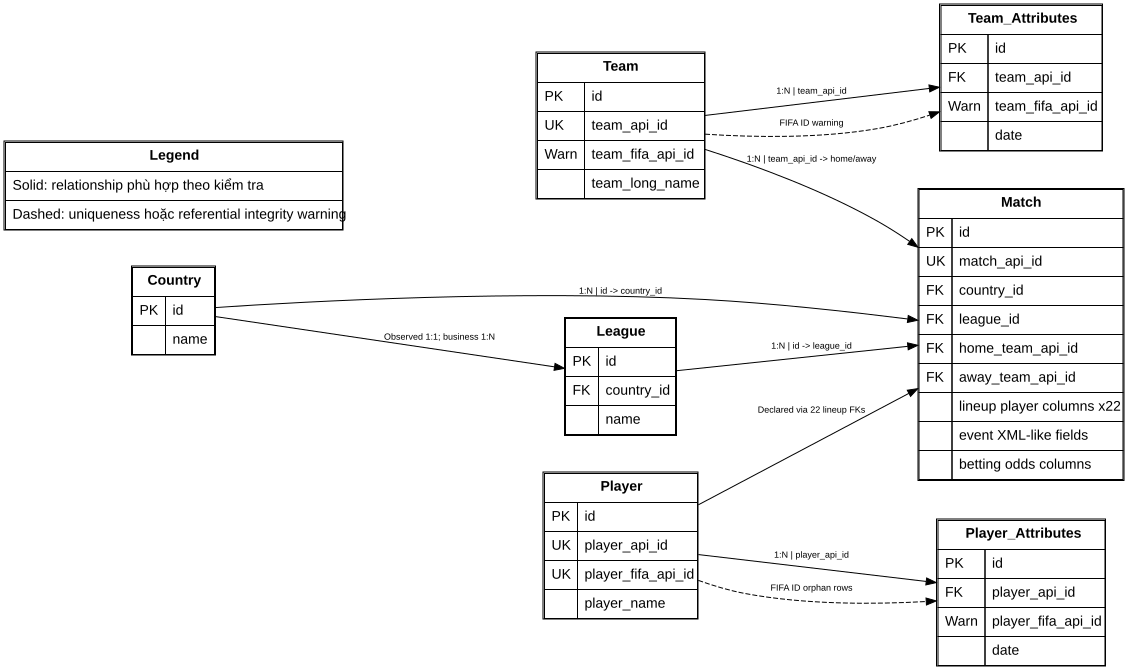

In [19]:
erd_tables = {
    "Country": [("PK", "id"), ("", "name")],
    "League": [("PK", "id"), ("FK", "country_id"), ("", "name")],
    "Match": [
        ("PK", "id"),
        ("UK", "match_api_id"),
        ("FK", "country_id"),
        ("FK", "league_id"),
        ("FK", "home_team_api_id"),
        ("FK", "away_team_api_id"),
        ("", "lineup player columns x22"),
        ("", "event XML-like fields"),
        ("", "betting odds columns"),
    ],
    "Team": [("PK", "id"), ("UK", "team_api_id"), ("Warn", "team_fifa_api_id"), ("", "team_long_name")],
    "Team_Attributes": [("PK", "id"), ("FK", "team_api_id"), ("Warn", "team_fifa_api_id"), ("", "date")],
    "Player": [("PK", "id"), ("UK", "player_api_id"), ("UK", "player_fifa_api_id"), ("", "player_name")],
    "Player_Attributes": [("PK", "id"), ("FK", "player_api_id"), ("Warn", "player_fifa_api_id"), ("", "date")],
}


def build_table_label(table_name: str, columns: list[tuple[str, str]]) -> str:
    rows = [f'<TR><TD COLSPAN="2"><B>{table_name}</B></TD></TR>']
    for key_type, column_name in columns:
        rows.append(f'<TR><TD ALIGN="LEFT">{key_type}</TD><TD ALIGN="LEFT">{column_name}</TD></TR>')
    return '<<TABLE BORDER="1" CELLBORDER="1" CELLSPACING="0" CELLPADDING="6">' + "".join(rows) + "</TABLE>>"


erd = Digraph(name="European_Soccer_Source_ERD", format="svg")
erd.attr("graph", rankdir="LR", ranksep="1.1", nodesep="0.5")
erd.attr("node", shape="plain", fontname="Arial")
erd.attr("edge", fontname="Arial", fontsize="9")

for table_name, columns in erd_tables.items():
    erd.node(table_name, label=build_table_label(table_name, columns))

lineup_edge_style = "solid" if bool(lineup_fk_summary.loc[0, "all_valid"]) else "dashed"

erd_edges = [
    ("Country", "League", "Observed 1:1; business 1:N", "solid"),
    ("Country", "Match", "1:N | id -> country_id", "solid"),
    ("League", "Match", "1:N | id -> league_id", "solid"),
    ("Team", "Match", "1:N | team_api_id -> home/away", "solid"),
    ("Team", "Team_Attributes", "1:N | team_api_id", "solid"),
    ("Player", "Match", "Declared via 22 lineup FKs", lineup_edge_style),
    ("Player", "Player_Attributes", "1:N | player_api_id", "solid"),
    ("Team", "Team_Attributes", "FIFA ID warning", "dashed"),
    ("Player", "Player_Attributes", "FIFA ID orphan rows", "dashed"),
]

for parent, child, label, style in erd_edges:
    erd.edge(parent, child, label=label, style=style)

erd.node(
    "Legend",
    label=(
        '<<TABLE BORDER="1" CELLBORDER="1" CELLSPACING="0" CELLPADDING="6">'
        '<TR><TD><B>Legend</B></TD></TR>'
        '<TR><TD ALIGN="LEFT">Solid: relationship phù hợp theo kiểm tra</TD></TR>'
        '<TR><TD ALIGN="LEFT">Dashed: uniqueness hoặc referential integrity warning</TD></TR>'
        '</TABLE>>'
    ),
)

display(erd)


**Nhận xét**

ERD thể hiện `Match` là bảng trung tâm, liên kết với `Country`, `League`, `Team` và `Player` thông qua các key đã kiểm tra. `Country–League` được ghi chú là `1:1 observed` trong dataset nhưng có thể mô hình hóa `1:N` theo business cardinality tổng quát. Các edge dùng `FIFA ID` được vẽ nét đứt vì có vấn đề uniqueness hoặc orphan rows, trong khi 22 lineup foreign keys đã được kiểm tra riêng trong phần referential integrity.


## 12. Kết luận

Database nguồn có cấu trúc quan hệ rõ ràng, trong đó `Match` là bảng sự kiện trung tâm và các bảng còn lại đóng vai trò mô tả hoặc snapshot thuộc tính theo thời gian. Các `api_id` như `match_api_id`, `team_api_id` và `player_api_id` đáng tin cậy hơn các `FIFA ID` trong các relationship chính.

Các vấn đề cần lưu ý gồm repeating groups và XML-like fields trong `Match`, `FIFA ID` chưa hoàn toàn đáng tin cậy, dependency gây dư thừa ở `Match` và `Team_Attributes`, cùng business key chưa ổn định ở các bảng thuộc tính. Những kết luận này phục vụ bước EDA tiếp theo, nơi cần kiểm tra missing values, duplicate, outlier, temporal coverage và mức độ phù hợp của dữ liệu với các câu hỏi phân tích.


In [20]:
connection.close()
print("SQLite connection closed.")


SQLite connection closed.
